In [45]:
# ================================
# IMPORT LIBRARIES
# ================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

import shap

In [46]:
# ================================
# LOAD DATASET
# ================================

df = pd.read_csv('heart.csv.xls')

# Display first rows
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## Dataset Overview

The UCI Heart Disease dataset was used for this project to investigate interpretable clinical risk prediction.

The dataset contains clinical and physiological variables associated with cardiovascular disease, including age, cholesterol, chest pain type, blood pressure, and exercise-induced angina.

The target variable represents the presence or absence of heart disease.

In [47]:
# ================================
# DATASET INFORMATION
# ================================

# Dataset shape
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Dataset information
print("\nDataset Info:")
df.info()

Dataset Shape: (1025, 14)

Columns:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


## Missing Value Analysis

The dataset was evaluated for missing values to ensure data quality and preprocessing consistency before model training.

In [48]:
# Check dataset information
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [49]:
# Check missing values
df1.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


## Statistical Summary

Descriptive statistical analysis was performed to understand the distribution and range of clinical variables within the dataset.

In [50]:
# Statistical summary
df1.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [51]:
df = df1

In [52]:
# Target distribution
print(df['target'].value_counts())

target
1    526
0    499
Name: count, dtype: int64


## Exploratory Data Analysis

Exploratory analysis was performed to understand the distribution of heart disease cases and identify relationships between clinical variables.

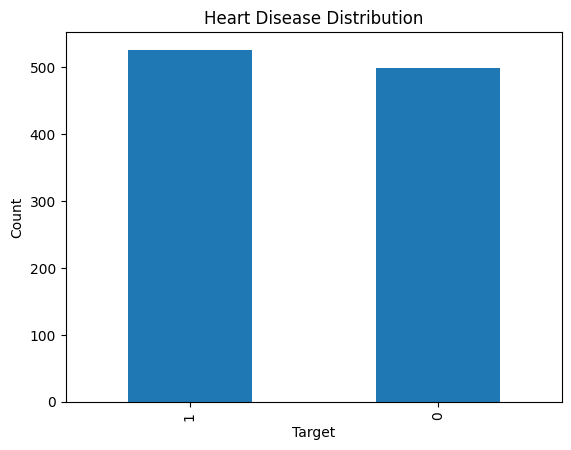

In [53]:
# Visualize target distribution
df['target'].value_counts().plot(kind='bar')

plt.title("Heart Disease Distribution")
plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

In [54]:
import seaborn as sns

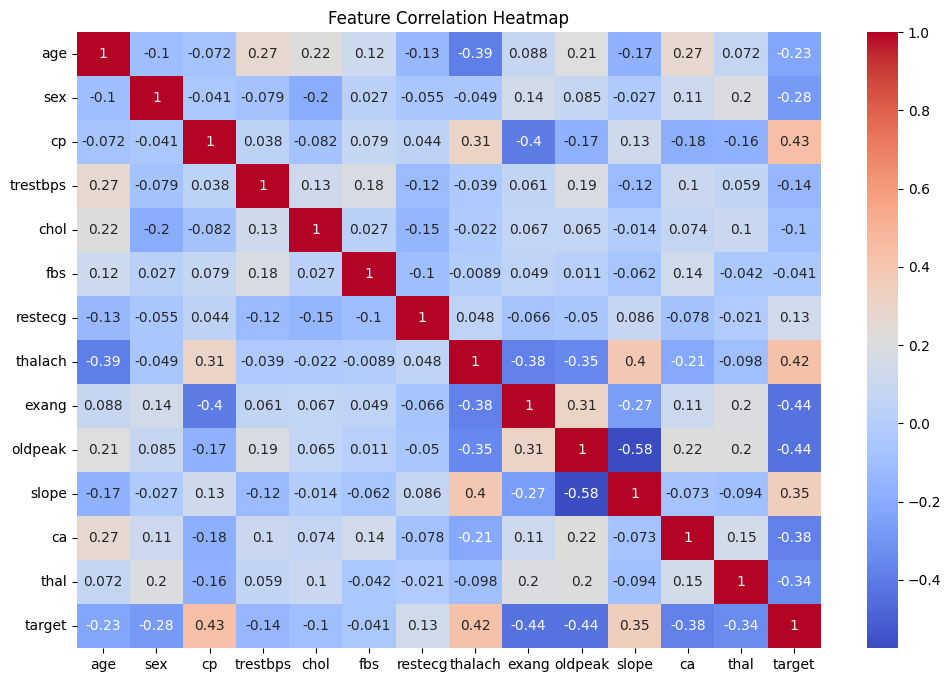

In [55]:
import seaborn as sns

# Correlation matrix
corr = df.corr()

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Feature Correlation Heatmap")
plt.show()

## Data Preprocessing

The dataset was prepared for machine learning by separating features and target variables, performing train-test splitting, and applying feature scaling where appropriate.

In [56]:
# Features
X = df.drop('target', axis=1)

# Target
y = df['target']

print(X.shape)
print(y.shape)

(1025, 13)
(1025,)


In [57]:
from sklearn.model_selection import train_test_split

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (820, 13)
Testing set: (205, 13)


In [58]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Scale features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Logistic Regression Model

Logistic Regression was used as an interpretable statistical baseline model for cardiovascular risk prediction.

In [59]:
from sklearn.linear_model import LogisticRegression

# Initialize model
log_model = LogisticRegression()

# Train model
log_model.fit(X_train_scaled, y_train)

LogisticRegression()

In [60]:
# Predictions
y_pred = log_model.predict(X_test_scaled)

In [61]:
from sklearn.metrics import accuracy_score

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression Accuracy:", accuracy)

Logistic Regression Accuracy: 0.7951219512195122


In [62]:
from sklearn.metrics import classification_report

# Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.72      0.78       102
           1       0.76      0.87      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.80      0.79       205



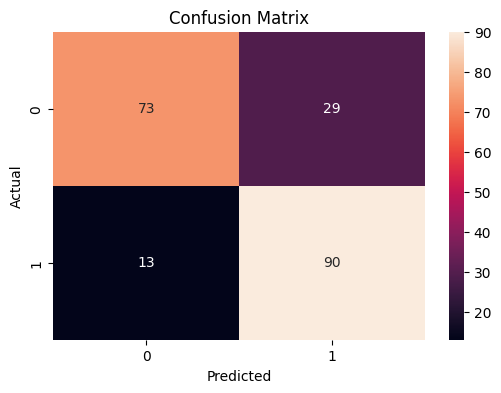

In [63]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

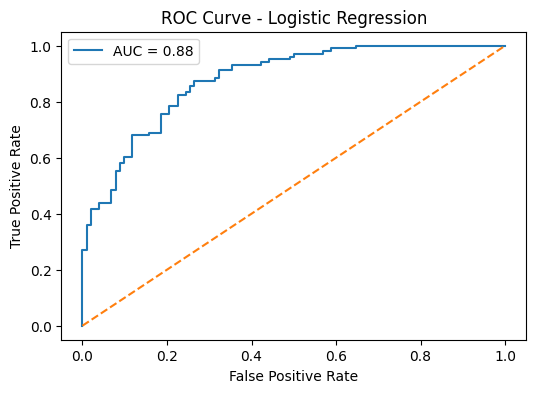

In [64]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probability predictions
y_prob = log_model.predict_proba(X_test_scaled)[:,1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC score
auc_score = roc_auc_score(y_test, y_prob)

# Plot ROC curve
plt.figure(figsize=(6,4))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.show()

## Random Forest Model

Random Forest was implemented as a machine learning ensemble model to compare predictive performance against Logistic Regression.

In [65]:
from sklearn.ensemble import RandomForestClassifier

In [66]:
# Initialize model
rf_model = RandomForestClassifier(random_state=42)

# Train model
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [67]:
# Predictions
rf_pred = rf_model.predict(X_test)

In [68]:
# Accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9853658536585366


In [69]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



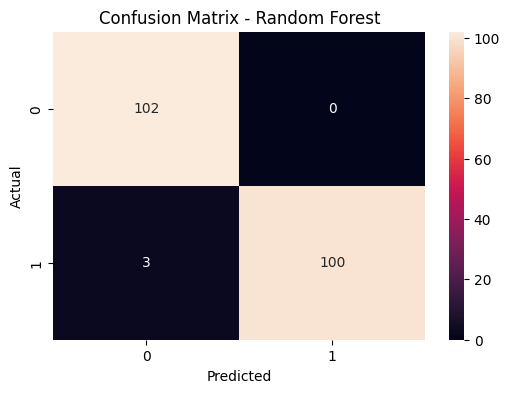

In [70]:
# Confusion matrix
rf_cm = confusion_matrix(y_test, rf_pred)

# Plot
plt.figure(figsize=(6,4))
sns.heatmap(rf_cm, annot=True, fmt='d')

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

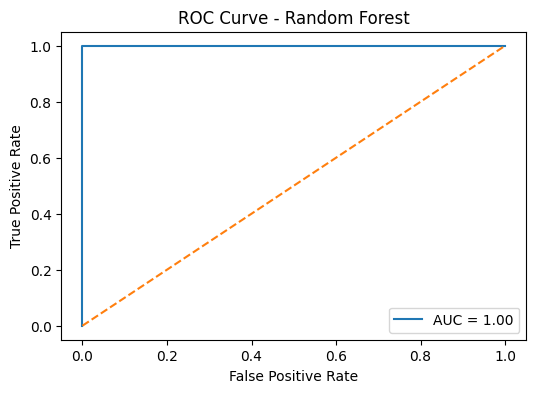

In [71]:
# Probability predictions
rf_prob = rf_model.predict_proba(X_test)[:,1]

# ROC values
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, rf_prob)

# AUC score
rf_auc = roc_auc_score(y_test, rf_prob)

# Plot
plt.figure(figsize=(6,4))

plt.plot(fpr_rf, tpr_rf, label=f"AUC = {rf_auc:.2f}")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")

plt.legend()

plt.show()

## Explainable AI using SHAP

SHAP explainability methods were applied to improve transparency and interpretability of machine learning predictions in clinical decision-support contexts.

In [72]:
!pip install shap

In [73]:
import shap

In [74]:
# Create SHAP explainer
explainer = shap.TreeExplainer(rf_model)

# Generate SHAP values
shap_values = explainer.shap_values(X_test)

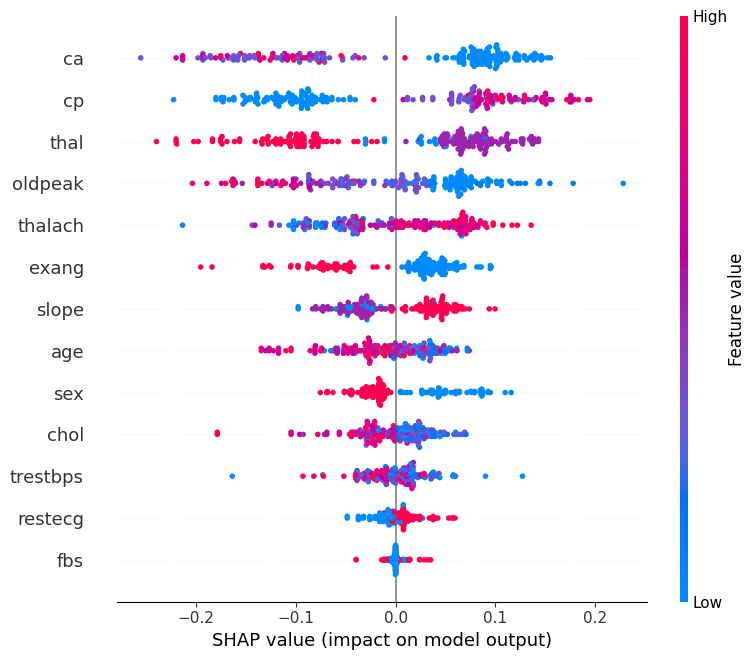

In [75]:
# SHAP summary plot
shap.summary_plot(shap_values[:,:,1], X_test)

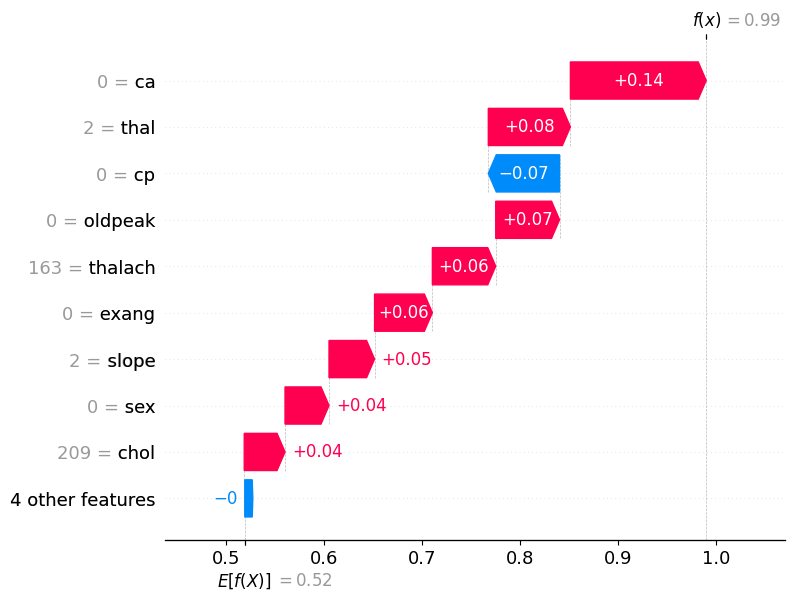

In [76]:
# Create SHAP explanation object
explanation = shap.Explanation(
    values=shap_values[:, :, 1][0],
    base_values=explainer.expected_value[1],
    data=X_test.iloc[0],
    feature_names=X_test.columns
)

# Waterfall plot
shap.plots.waterfall(explanation)

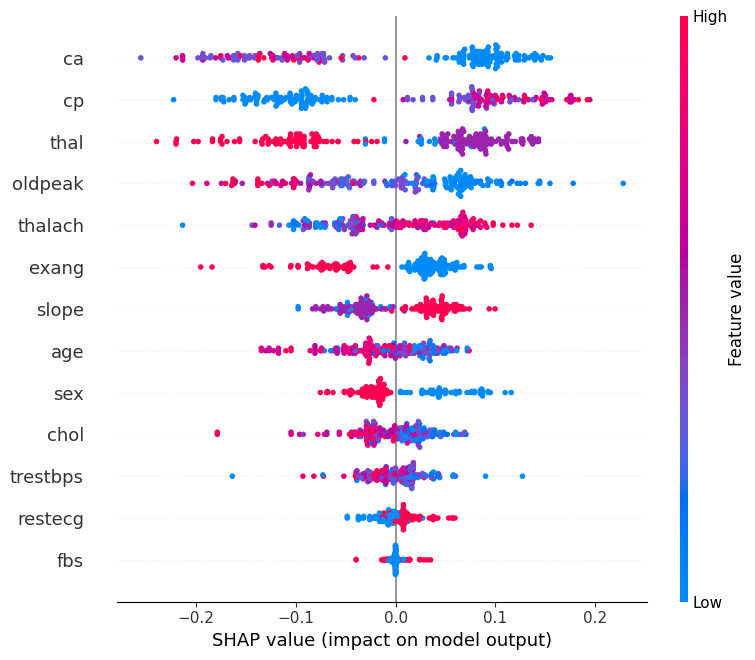

In [77]:
# SHAP summary plot
shap.summary_plot(shap_values[:, :, 1], X_test)

In [78]:
# Model comparison table

comparison = {
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy, rf_accuracy],
    "AUC Score": [auc_score, rf_auc]
}

comparison_df = pd.DataFrame(comparison)

comparison_df

,Model,Accuracy,AUC Score
0,Logistic Regression,0.795122,0.878736
1,Random Forest,0.985366,1.000000


## Model Interpretation

Logistic Regression provided interpretable statistical predictions with strong transparency, making it suitable for clinically understandable decision support.

Random Forest achieved higher predictive performance but introduced reduced interpretability due to its ensemble-based architecture.

SHAP explainability techniques were applied to improve transparency and identify the most influential clinical features contributing to heart disease prediction.

## Explainable AI Analysis

SHAP analysis identified important predictors including chest pain type (`cp`), oldpeak, maximum heart rate (`thalach`), and number of major vessels (`ca`).

The explainability framework enabled both global and local interpretation of model predictions, improving transparency for potential clinical decision-support applications.

Local waterfall explanations demonstrated how individual patient features contributed positively or negatively toward predicted cardiovascular risk.

## Feature Importance Analysis

Feature importance analysis was performed to identify the most influential clinical variables contributing to heart disease prediction.

In [79]:
# Extract feature importance
importances = rf_model.feature_importances_

# Create dataframe
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

# Sort values
feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

# Display table
feature_importance_df

,Feature,Importance
2,cp,0.135072
11,ca,0.127327
7,thalach,0.122169
9,oldpeak,0.121905
12,thal,0.110518
0,age,0.077908
4,chol,0.074822
3,trestbps,0.071171
8,exang,0.057594
10,slope,0.045782


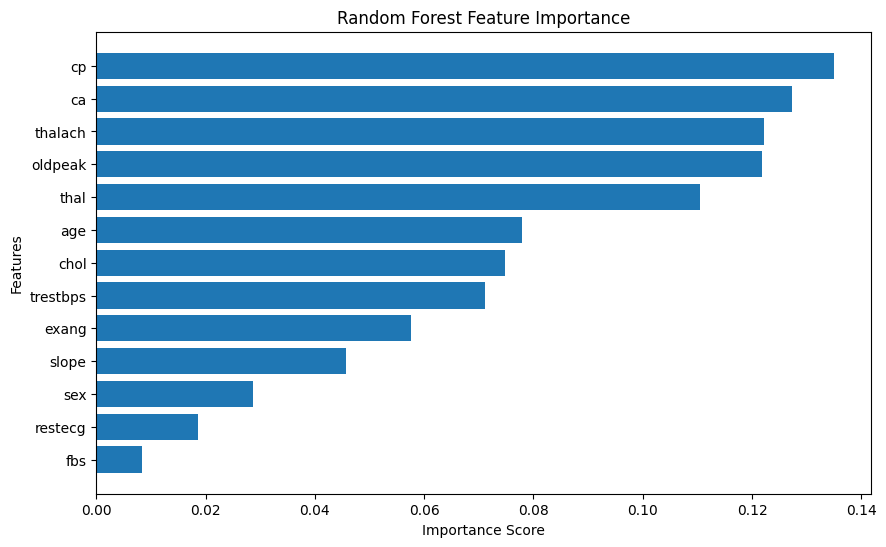

In [80]:
# Plot feature importance

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance_df['Feature'],
    feature_importance_df['Importance']
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

##Conclusion

This project demonstrated the use of interpretable statistical and machine learning models for heart disease prediction.

Logistic Regression provided transparent and clinically interpretable predictions, while Random Forest improved predictive performance.

SHAP explainability methods enabled both global and local interpretation of predictions, supporting the development of more trustworthy AI-assisted clinical decision systems.